<center>

Lab session 5

Cerca i Anàlisi de la Informació (CAI)  

David González · Angel Morales  

Python Notebook

</center>


The code cells should be executed in order to avoid unpredicted behavior and errors.

## Dependencies

In [6]:
# Needed modules
# Uncomment the last line to install the needed dependencies

def install_dependencies() -> None:
    """Install the required dependencies."""
    %pip install matplotlib
    %pip install pandas
    %pip install seaborn
    %pip install pympler
    %pip install scipy
    %pip install tqdm

#install_dependencies()

In [7]:
# Needed modules

import hashlib
import math
import pickle
import random
import urllib
from itertools import combinations
from pathlib import Path
from time import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pympler.asizeof import asizeof
from scipy.stats import norm
from tqdm import tqdm

## Exercise 2
The teacher has provided us with a template to build the code which, given a document, returns its simhash, just the way we did for the toy example in exercise 1. She has also given us some auxiliary functions to compute hashes and load the document to perform the tests.

In [8]:
# Given auxiliar function to compute hashes.

def _termhash(x : str, b : int) -> str:
    """returns bitstring of size b based on md5 algorithm"""
    assert b <= 128, 'this encoding scheme supports hashes of length at most 128; try smaller b'
    h = hashlib.md5(x.encode('utf8')).digest()
    return ''.join(format(byte, '08b') for byte in h)[:b]

for w in ['bit', 'coin', 'hola que tal']:
    print(f'hash.md5({w}) = {_termhash(w, 4)}')

hash.md5(bit) = 1111
hash.md5(coin) = 1001
hash.md5(hola que tal) = 0110


### Loading tf-idf for the whole corpus

As stated by the teacher, she has provided us with "the document-term matrix with normalized tf-idf weights with a sparse representation". This avoids the overhead of repeatedly asking elasticsearch for the information.

The following code downloads the corpus data from https://www.cs.upc.edu/~marias/05arxiv.pkl (if not found locally), and loads the corpus data into a `corpus` forward index for the `arxiv` repository.

In [9]:
# Given code to load the data

fname = "05arxiv.pkl"
url = "http://www.cs.upc.edu/~marias/05arxiv.pkl"

if Path(fname).exists():
    print(f"File '{fname}' already exists. Skipping download.")
else:
    print(f"File '{fname}' not found. Downloading from {url}...")    
    urllib.request.urlretrieve(url, Path(fname))            
    print(f"Successfully downloaded and saved '{fname}'.")

# load data..
with open(fname, 'rb') as f:
    corpus = pickle.load(f)

File '05arxiv.pkl' not found. Downloading from http://www.cs.upc.edu/~marias/05arxiv.pkl...
Successfully downloaded and saved '05arxiv.pkl'.


Loaded corpus with 58102 documents.
A few document ids are: ['10828', '15821', '2011', '23724', '25926', '29830', '3724', '4118', '4323', '5279']
Each document is a dictionary with term -> tf-idf weights, e.g. the first:
{'aboard': np.float64(0.07545263523439706), 'abridged': np.float64(0.04704103382533448), 'absence': np.float64(0.041260219404163065), 'accretion': np.float64(0.07489199382722006), 'acquire': np.float64(0.05593322241898868), 'also': np.float64(0.009496865784902367), 'area': np.float64(0.03399071022088104), 'assembled': np.float64(0.06033120434565402), 'balmer': np.float64(0.06470369207056549), 'based': np.float64(0.011276150275484799), 'because': np.float64(0.02821273654454122), 'below': np.float64(0.0338553093134177), 'beta': np.float64(0.03834411519846773), 'bh': np.float64(0.10402919480643208), 'billion': np.float64(0.05871532566448025), 'black': np.float64(0.13677933142456272), 'break': np.float64(0.09070913569070713), 'brighter': np.float64(0.1135656388451571), 'ce

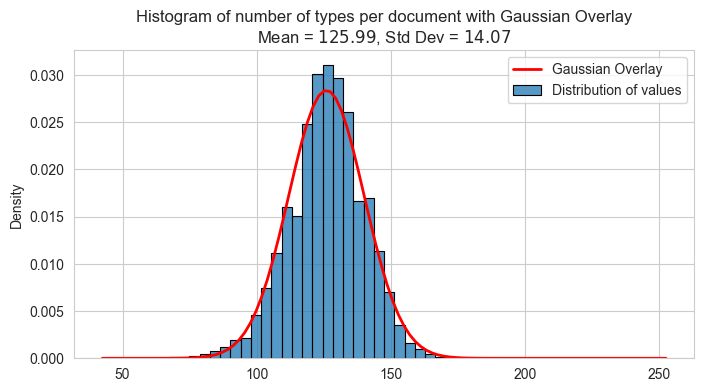

In [10]:
# Given code to display some metadata

# show contents
print(f"Loaded corpus with {len(corpus)} documents.")
all_document_ids = list(corpus.keys())
print(f"A few document ids are: {sorted(random.sample(all_document_ids, 10))}")
print(f"Each document is a dictionary with term -> tf-idf weights, e.g. the first:")
print(corpus[all_document_ids[0]])

# obtain histogram with nr of terms in each document
values = [len(corpus[id]) for id in all_document_ids]
mu = np.mean(values)
sigma = np.std(values)
plt.figure(figsize=(8, 4))
sns.set_style("whitegrid")
sns.histplot(values, bins=50, edgecolor='black', stat='density', label='Distribution of values')
plt.title(f'Histogram of number of types per document with Gaussian Overlay\nMean = ${mu:.2f}$, Std Dev = ${sigma:.2f}$', fontsize=12)
xmin, xmax = plt.xlim()
x_axis = np.linspace(xmin, xmax, 100)

# Calculate the probability density function (PDF) for the x-values.
plt.plot(x_axis, norm.pdf(x_axis, mu, sigma), 'red', linewidth=2, label='Gaussian Overlay')
plt.legend(); # Display the labels

In [11]:
# Exercise 2: function to compute the simhash

## constants
K = 18
M = 3
B = M*K

def _simhash(id: str, b: int) -> list[int]:
    """
        id is the document id, b is the desired length of the simhash
        it should return a bitstring of length b as explained in the
        first section of the notebook
    """

    # Access document
    words_weights: dict[str, np.float] = (corpus[id]) # dict[word: tf-idf]
    #print(words_weights) # debug
    bitstrings: list[list[int]] = []
    # For each word, compute the _termhash(w, b)
    for word, weight in words_weights.items():
        bitstring = _termhash(word, b)
        
        # Replace 0 with -1
        new_bitstring = []
        for char in bitstring:
            if char == "1": new_bitstring.append(weight)
            elif char == "0": new_bitstring.append(-weight)
            else: raise ValueError("One bit is not 0 neither 1.")
        assert len(new_bitstring) == b

        bitstrings.append(new_bitstring)

    # Follow instructions to compute the simhash of the document (round to +-1, sum, round to 1, 0)
    doc_hash = [sum(bitstrings[w][bit] for w in range(len(bitstrings))) for bit in range(b)]
    assert len(doc_hash) == b

    # Replace positives with 1 and negatives with 0
    new_doc_hash = []
    for item in doc_hash:
        if item > 0: new_doc_hash.append(1)
        else: new_doc_hash.append(0)
    assert len(new_doc_hash) == b

    return new_doc_hash

Now, the following line of code computes the simhash of every document, and stores them in a dictionary where the keys are document IDs, and the values are the simhashes, stored in a list where each element is one bit. We can take a look at one example.

In [12]:
## simhash stores all simhashes of the whole corpus in a dictionary
simhash = {id: _simhash(id, B) for id in tqdm(corpus)}

100%|██████████| 58102/58102 [01:19<00:00, 734.86it/s]


In [13]:
print(simhash["22141"])

[1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1]


## Exercise 3

In [14]:
def place_in_buckets(simhash: dict[str, list[int]], m: int, k: int):
    """
    Given a dictionary with the simnhash for each document id, distribute it in M buckets of size K.
    """

    hash_table = [[[] for _ in range(2**k)] for _ in range(m)]
    for document, bitstring in simhash.items():
        # For each group of k bits, add the base 10 number formed by them to the corresponding bucket
        for repetition in range(m):
            bits = bitstring[repetition*k : (repetition+1)*k]
            bucket = int(''.join(map(str, bits)), 2) # Transform the binary number represented by the bits to a base 10 integer
            hash_table[repetition][bucket].append(document)
    return hash_table

In [15]:
def check_collisions(simhash, m: int, k: int) -> tuple[set[set[str]], float]:
    """
    Check which pairs of documents collide inside the corpus.
    Return the set of collided pairs and the size of the hash table in GBs.
    """
    try:
        assert len(next(iter(simhash.values()))) == m*k
    except:
        print(m)
        print(k)
        print(len(next(iter(simhash.values()))))
        assert True
        
    hash_table = place_in_buckets(simhash, m, k)

    collided_pairs: set[set[str]] = set()
    for section in hash_table:
        for bucket in section:
            if len(bucket) > 1:
                for i in range(len(bucket)):
                    doc1 = bucket[i]
                    for j in range(i+1, len(hash_table)):
                        try:
                            doc2 = bucket[j]
                            collided_pairs.add((doc1, doc2))
                        except IndexError:
                            pass
    return collided_pairs, asizeof(hash_table) / 1024**3

This two functions compute the hash table and then check for collisions, respectively. For example, we can now look at how many collisions there are for the prior simhash we computed, and see some example of pairs which have collided.

In [16]:
N_PAIRS_TO_PRINT = 10

similar_pairs, hash_size_gbs = check_collisions(simhash, M, K)

print(f"Number of collisions (pairs): {len(similar_pairs)}")
print(f"Size of the hash table in GBs: {hash_size_gbs}")
print("Some examples:")
pairs_iter = iter(similar_pairs)
for i in range(N_PAIRS_TO_PRINT):
    print(f"     {next(pairs_iter)}")

Number of collisions (pairs): 32706
Size of the hash table in GBs: 0.054291412234306335
Some examples:
     ('45845', '46039')
     ('12275', '14085')
     ('14189', '41590')
     ('34881', '34901')
     ('20045', '55238')
     ('23730', '42722')
     ('39038', '40717')
     ('19388', '57693')
     ('10374', '37020')
     ('33770', '53933')


Now it is interesting to see if those pairs are actually similar. The next function computes the cosine similarity of 2 documents represented in this format (foward index). Is is not fully efficient because we compute the norm of each document every time it collides, and we could store the norms in some structure which allows us to reuse them.

In [17]:
def cosine_similarity(doc1, doc2):
    # dot product
    dot_prod = sum(doc1[w] * doc2[w] for w in doc1 if w in doc2)
    # norms
    norm1 = math.sqrt(sum(v*v for v in doc1.values()))
    norm2 = math.sqrt(sum(v*v for v in doc2.values()))
    # similarity
    return dot_prod / (norm1 * norm2)

In [18]:
N_PAIRS_TO_PRINT = 10

similar_pairs, _ = check_collisions(simhash, M, K)

print(f"Number of collisions (pairs): {len(similar_pairs)}")
print("Some examples:")
print("\tPair 1".ljust(10), "Pair 2".ljust(10), "Cosine similarity\n\t--------------------------------------")
pairs_iter = iter(similar_pairs)
for i in range(N_PAIRS_TO_PRINT):
    pair = next(pairs_iter)
    print(f"\t{pair[0]:<10}{pair[1]:<10}{cosine_similarity(corpus[pair[0]], corpus[pair[1]]):.3f}")

Number of collisions (pairs): 32706
Some examples:
	Pair 1    Pair 2     Cosine similarity
	--------------------------------------
	45845     46039     0.944
	12275     14085     0.982
	14189     41590     1.000
	34881     34901     0.979
	20045     55238     1.000
	23730     42722     0.974
	39038     40717     1.000
	19388     57693     1.000
	10374     37020     0.007
	33770     53933     0.015


Interestingly, some pairs have a very low similarity, but others are very high. (The simhash dictionary varies in each execution, and in some executions we managed to get 2 pairs with a similarity of 1 out of those 10 samples!)

Now it is time to decide on a threshold. For example, 0.9.

In [19]:
THRESHOLD = 0.9

In [20]:
def hash_positives(m: int = M, k: int = K, threshold: int = THRESHOLD) -> tuple[float, float, float]:
    """
    Given parameters m and k, create the simhash table and return a tuple with:
    - number of true positives (TP)
    - number of false positives (FP)
    - size of the hash table in GBs
    """

    simhash = {id: _simhash(id, m*k) for id in tqdm(corpus)}

    similar_pairs, hash_size_gbs = check_collisions(simhash, m, k)

    tp = 0
    fp = 0
    for pair in similar_pairs:
        assert pair[0] != pair[1]
        if cosine_similarity(corpus[pair[0]], corpus[pair[1]]) >= threshold:
            tp += 1
        else:
            fp += 1

    return tp, fp, hash_size_gbs

In [21]:
tp, fp, _ = hash_positives()
print(tp, fp)

  0%|          | 0/58102 [00:00<?, ?it/s]

100%|██████████| 58102/58102 [01:19<00:00, 727.12it/s]


13463 19243


We see that, with this threshold, there are around 13 thousand true positives and 19 thousand false positives. Lowering the threshold would increase the true positives, thus the overall accuracy. But before trying that, we can try to get a higuer accuracy with different m and k parameters.

In [22]:
def run_experiment(parameter_pairs: list[tuple[int, int]], threshold: int = THRESHOLD) -> pd.DataFrame:
    """Given some initial and final ranges for m and k, evaluate the hash accuracy and recall."""

    total_iterations = len(parameter_pairs)

    experiment_results = pd.DataFrame(columns=[
        "m", "k", "Hits", "TP", "FP", "Accuracy", "Hash computation time", "Hash size (GBs)"
    ])

    with tqdm(total=total_iterations, desc="Running LSH Experiments") as pbar:
        for (m, k) in parameter_pairs:
            
            t0 = time()
            tp, fp, hash_size_gbs = hash_positives(m, k, threshold)
            hash_time = time() - t0

            hits = tp + fp
            accuracy = tp / hits if hits > 0 else 1

            experiment_results.loc[len(experiment_results)] = {
                "m": m,
                "k": k,
                "Hits": hits,
                "TP": tp,
                "FP": fp,
                "Accuracy": accuracy,
                "Hash computation time": hash_time,
                "Hash size (GBs)": hash_size_gbs
            }

            pbar.update(1)

    return experiment_results

In [46]:
def plot_heatmap(df, metric="Accuracy", decimals=4):
    """Plot the heatmap of the chosen metric for the results, by m and k."""
    heatmap_data = df.pivot(index="m", columns="k", values=metric)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=f".{decimals}f",
        cmap="viridis"
    )
    plt.title(f"{metric} heatmap")
    plt.ylabel("m")
    plt.xlabel("k")
    plt.show()

In [24]:
parameter_pairs = [
    (1, 10), (1, 18), (1, 23),
    (3, 10), (M, K), (3, 23),
    (5, 10), (5, 18), (5, 23)
]

results1 = run_experiment(parameter_pairs)

Running LSH Experiments: 100%|██████████| 9/9 [13:41<00:00, 91.28s/it] 


In [25]:
results1

,m,k,Hits,TP,FP,Accuracy,Hash computation time,Hash size (GBs)
0,1,10,0,0,0,1.000000,42.551983,0.003568
1,1,18,0,0,0,1.000000,50.105449,0.020119
2,1,23,0,0,0,1.000000,63.480272,0.507493
3,3,10,9179,118,9061,0.012855,63.206190,0.004644
4,3,18,32706,13463,19243,0.411637,85.000998,0.054291
5,3,23,13943,13177,766,0.945062,129.108942,1.516418
6,5,10,50893,390,50503,0.007663,80.829140,0.005721
7,5,18,54051,16356,37695,0.302603,118.631979,0.088483
8,5,23,17217,15724,1493,0.913283,188.599383,2.525341


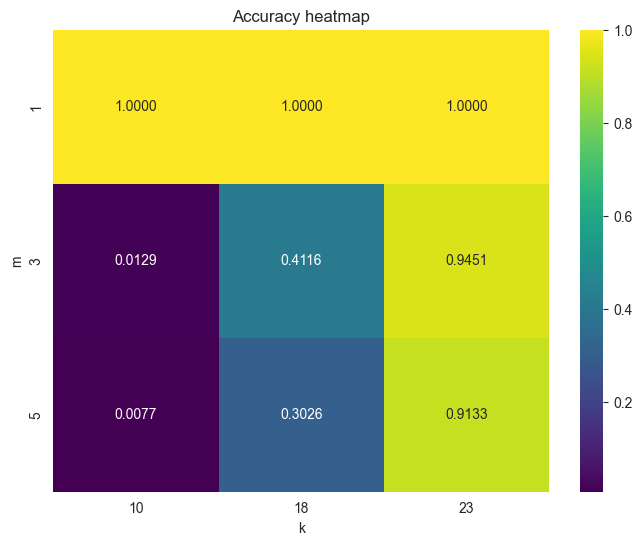

In [47]:
plot_heatmap(results1, "Accuracy")

After trying with some various combinations of parameters, we see that that:

- Low k causes almost all collisions to be false positives.

- Low m causes collisions to be too unlikely, and we can get cases with zero hits.

- Combinations (3, 25) and (5, 25) had the best accuracies, although they have the highest computation time.

We can now try to get a higher accuracy, but we may sacrifice the computation time and need much more memory. The best result until now was m = 3 and k = 23, with an accuracy of 0.945.

In [ ]:
# WARNING: this cell requires several resources to compute (more than 8GBs RAM, 20 minutes time)

parameter_pairs = [
    (2, 24), (2, 25),
    (3, 24), (3, 25),
    (4, 24), (4, 25)
]

results2 = run_experiment(parameter_pairs)

Running LSH Experiments: 100%|██████████| 6/6 [19:18<00:00, 193.02s/it]


In [28]:
results2

,m,k,Hits,TP,FP,Accuracy,Hash computation time,Hash size (GBs)
0,2,24,10193,9990,203,0.980084,116.228583,2.021664
1,2,25,10062,9956,106,0.989465,162.006749,4.044749
2,3,24,13542,13104,438,0.967656,161.656059,3.030981
3,3,25,13290,13055,235,0.982318,230.215361,6.065606
4,4,24,15586,14957,629,0.959643,198.857278,4.040297
5,4,25,15251,14890,361,0.976329,289.158406,8.086463


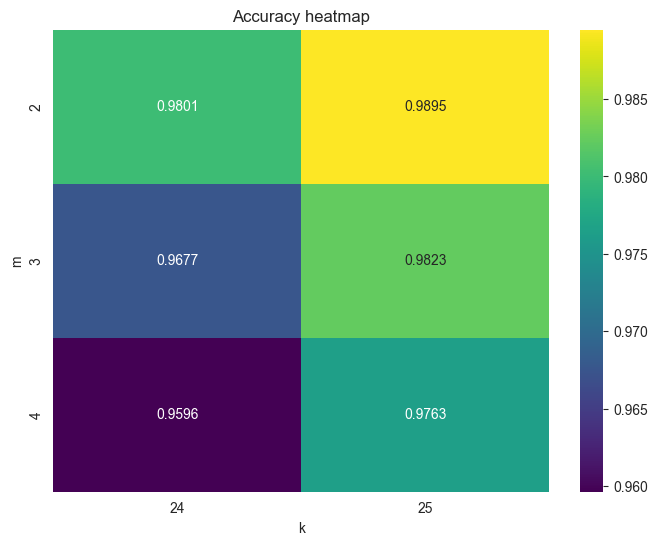

In [29]:
plot_heatmap(results2, "Accuracy")

We see that increasing k and lowering m seems the combination with the highest accuracy. We can try to get even better results, but we have to be careful because the memory usage is exploding, and we already managed to occupy 8GBs for the hash table with m = 3 and k = 25.

In [ ]:
# WARNING: this cell requires several resources to compute (more than 16GBs RAM, 15 minutes time)

parameter_pairs = [
    (2, 26), (2, 27)
]

results3 = run_experiment(parameter_pairs)

Running LSH Experiments: 100%|██████████| 2/2 [14:15<00:00, 427.78s/it]


In [35]:
results3

,m,k,Hits,TP,FP,Accuracy,Hash computation time,Hash size (GBs)
0,2,26,9983,9929,54,0.994591,371.946769,8.098360
1,2,27,9923,9888,35,0.996473,483.527860,16.220685


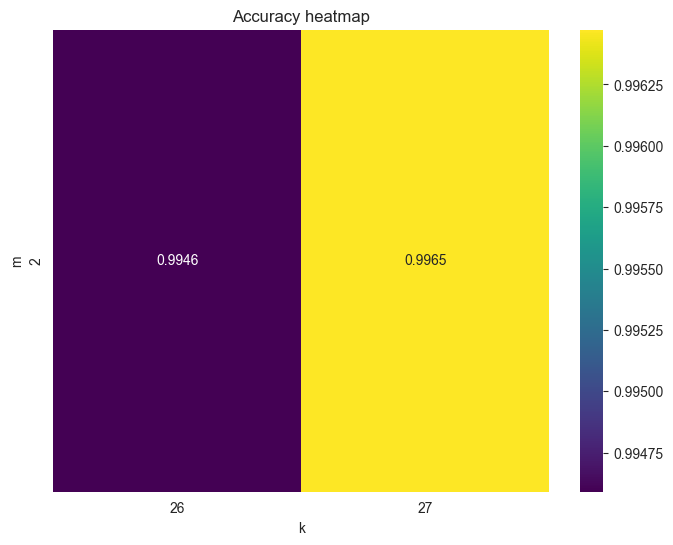

In [36]:
plot_heatmap(results3, "Accuracy")

Increasing k from 26 to 27 causes an increase of the accuracy of a 0.002, relatively imperceptible, and doubles the memory usage from 8 to 16 GBs. We are being clearly too greedy.

Lets see our results and discuss which are the best combinations.

In [37]:
results = pd.concat([results1, results2, results3])

results

,m,k,Hits,TP,FP,Accuracy,Hash computation time,Hash size (GBs)
0,1,10,0,0,0,1.000000,42.551983,0.003568
1,1,18,0,0,0,1.000000,50.105449,0.020119
2,1,23,0,0,0,1.000000,63.480272,0.507493
3,3,10,9179,118,9061,0.012855,63.206190,0.004644
4,3,18,32706,13463,19243,0.411637,85.000998,0.054291
5,3,23,13943,13177,766,0.945062,129.108942,1.516418
6,5,10,50893,390,50503,0.007663,80.829140,0.005721
7,5,18,54051,16356,37695,0.302603,118.631979,0.088483
8,5,23,17217,15724,1493,0.913283,188.599383,2.525341
0,2,24,10193,9990,203,0.980084,116.228583,2.021664


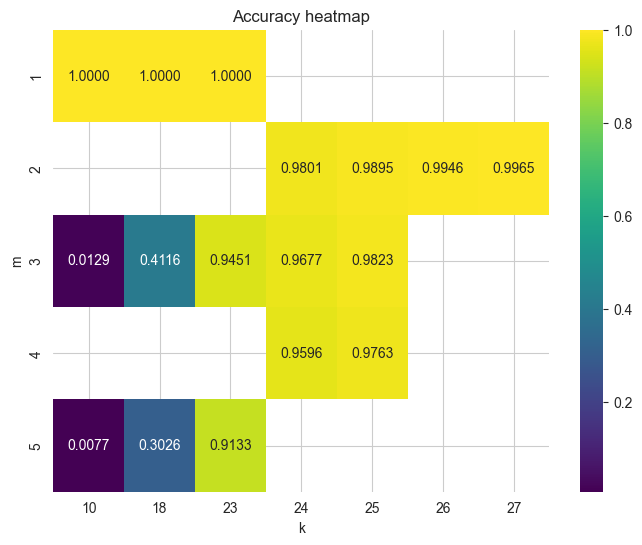

In [39]:
plot_heatmap(results, "Accuracy")

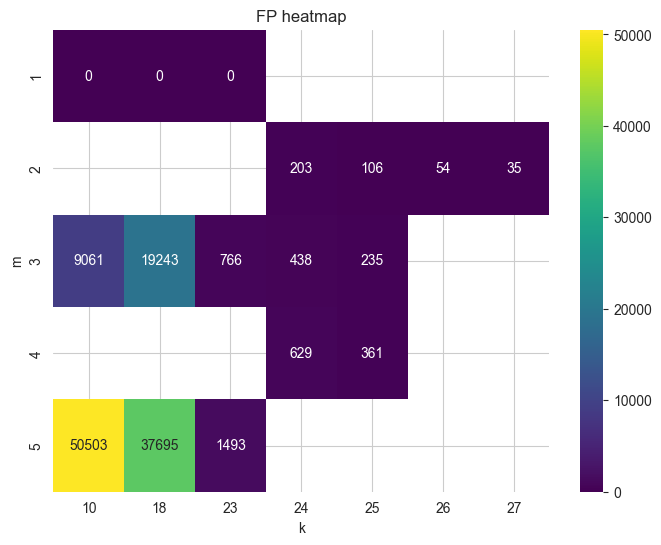

In [ ]:
plot_heatmap(results, "FP", decimals=0)

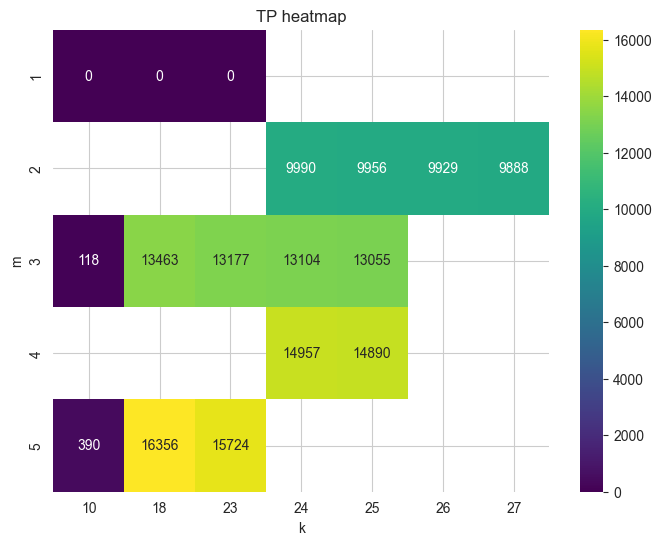

In [52]:
plot_heatmap(results, "TP", decimals=0)

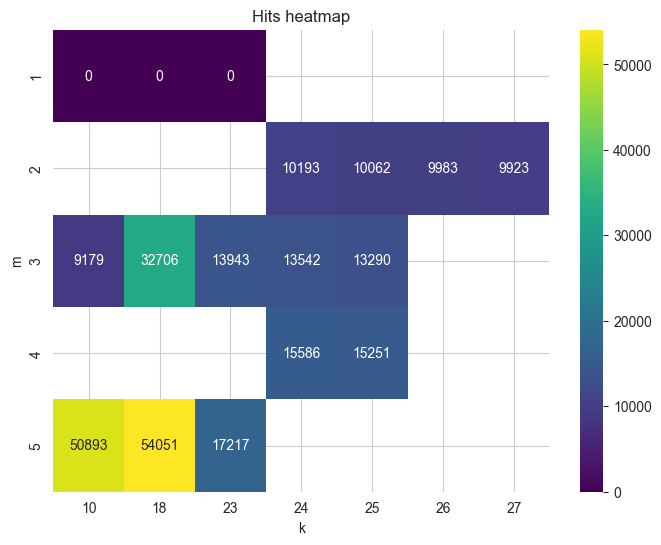

In [ ]:
plot_heatmap(results, "Hits", decimals=0)

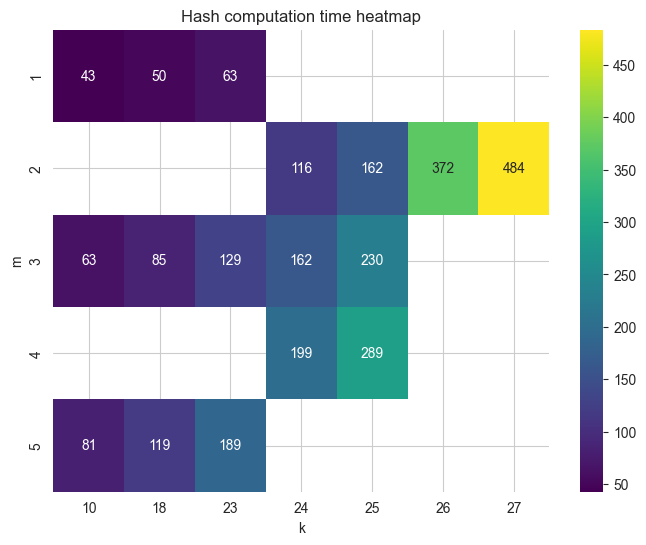

In [ ]:
plot_heatmap(results, "Hash computation time", decimals=0)

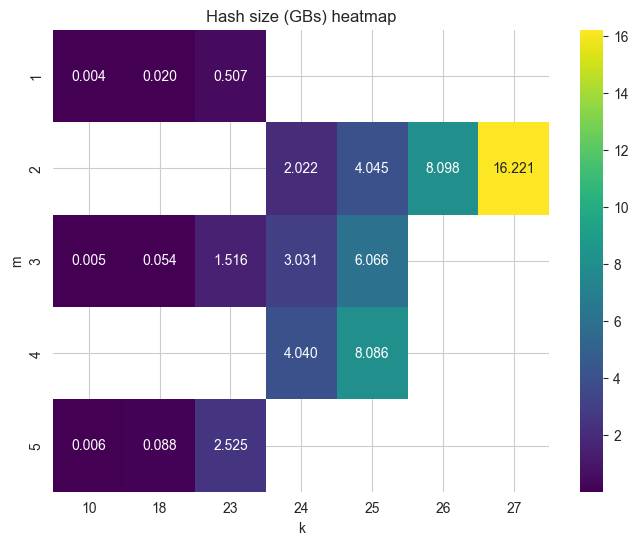

In [51]:
plot_heatmap(results, "Hash size (GBs)", decimals=3)

In terms of accuracy, we start to see acceptable rates for k = 23 (probably k can be a bit smaller), and we need m to be at least 2. In fact, m should not be greater than 2 to avoid losing accuracy. If, instead, we wanted to maximize recall (we will later talk about this metric), we may want to increase m.

If our system is capable of handling between 2 and 6 GBs, which is something usual nowadays that most systems have 16GBs, we can opt for a k around 24 and 25, and m around 2 and 3. This will give us a pretty good accuracy around 0.97. If we want to achieve high accuracy with lower resource consumption, k should be 23 and m should be 2.

If we have spare memory (32GBs or more), we can set k to 26 and m to 2 or probably even 3. We could even set k to 27, but it is not worth doubling the RAM usage to have an increase of around a 0.002%.

For every case, we may expect the computation time to be around 2 or 3 minutes, larger times if our system has a modest processor.

What about recall? Recall can only be computed if we know the true number of duplicates in our corpus. Doing this by brute force would imply computing the cosine similarity of each pair of documents, which means computing the 60 thousand norms, the 120 million cosine similarities, and the thousands of millions of products needed to do that. We can't even estimate how long it would take.

What we can actually estimate is an upper bound for the recall. We can see that for m = 5, k = 18, there are 16.356 true positives, which means that the number of positives inside the corpus is at least this big. We can divide the number of true positives by this number to get an upper bound for the recall on every tested case.


In [56]:
results["recall upper bound"] = results["TP"] / max(results["TP"])

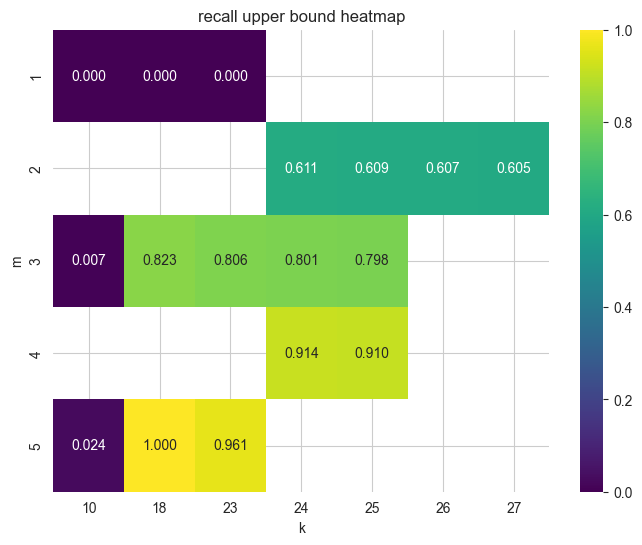

In [57]:
plot_heatmap(results, "recall upper bound", decimals=3)

And now we finally see how the balance between accuracy and recall is present in a practical case. Increasing both is much more expensive than sacrificing one of them in exchange for the other.

"To improve accuracy, increase k."

"To improve recall, increase m."

Of course, be careful not to increase them too much, or be ready to have your resources consumed.